(lecture06:homework)=
# Homework 6

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name: Pranay**
+ **Last Name: Gohel**
+ **Email: gohelp@purdue.edu**

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')
import requests
import os
def download(url, local_filename=None):
    """
    Downloads the file in the ``url`` and saves it in the current working directory.
    """
    data = requests.get(url)
    if local_filename is None:
        local_filename = os.path.basename(url)
    with open(local_filename, 'wb') as fd:
        fd.write(data.content)

/tmp/ipython-input-1846507495.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


## Problem 1 - Loops and conditionals

Consider the following list:

In [2]:
data = [1, 4, 3, 10, 4, 3, 4, 4]

+ Write a loop that computes the average of the elements in the list and ``print`` the result using two significant digits.

In [4]:
n = len(data)
sum = 0.0
for i in data:
    sum += i
average = sum / n
print(f'Average of List = {average:1.2f}')

Average of List = 4.12


+ Write code that finds the number of times the element 4 occurs in the list. Hint: Use a loop and an if-statement.

In [5]:
count = 0
for i in data:
    if i == 4:
        count += 1
print(f"The number 4 occurs {count} times in the given list.")

The number 4 occurs 4 times in the given list.


+ Write a Python function that takes a list as an argument and returns the number of times a given element (also passed as an argument to the function) appears in the list. Call that function ``find_number_of_occurences(a, elm)``. Make sure you follow best practices when writing the docstring of your function.

In [10]:
def find_number_of_occurences(a, elm):
    """
    This function returns the number of times a given element (given as an input) appears in a list.
    Parameters:
    a (list): List to search through.
    elm: Element to count appearances for.

    Returns:
    int: The total count of how many times elm appears in list a.
    """
    count = 0
    for i in a:
        if i == elm:
            count += 1
    return count

In [11]:
# Try your code here:
help(find_number_of_occurences)

Help on function find_number_of_occurences in module __main__:

find_number_of_occurences(a, elm)
    This function returns the number of times a given element (given as an input) appears in a list.
    Parameters:
    a (list): List to search through.
    elm: Element to count appearances for.

    Returns:
    int: The total count of how many times elm appears in list a.



In [12]:
# Try your code here:
find_number_of_occurences(data, 4)

4

+ Write a Python function that takes a list as an argument and returns the number of elements that are greater than a given element (also passed as an argument to the function). Call that function ``find_number_of_elms_greater_than(a, elm)``. Make sure you follow best practices when writing the docstring of your function.

In [13]:
def find_number_of_elms_greater_than(a, elm):
    """
    This function returns the number of elements in a list that are greater than a given (user inputted) value.
    Parameters:
    a (list): List to check through.
    elm: Threshold value supplied by user.

    Returns:
    int: Count of elements in List a that are greater than elm.
    """
    count = 0
    for i in a:
        if i > elm:
            count += 1
    return count

In [14]:
# Try your code here:
help(find_number_of_elms_greater_than)

Help on function find_number_of_elms_greater_than in module __main__:

find_number_of_elms_greater_than(a, elm)
    This function returns the number of elements in a list that are greater than a given (user inputted) value.
    Parameters:
    a (list): List to check through.
    elm: Threshold value supplied by user.

    Returns:
    int: Count of elements in List a that are greater than elm.



In [15]:
# Try your code here:
find_number_of_elms_greater_than(data, 3)

5

## Problem 2 - High-performance buildings revisited

In this problem we will continue analyzing the high-performance buildings dataset we introduced in {ref}`lecture03:homework:problem1` and with which we played in {ref}`lecture06:selecting-rows`.
Let me set you up by downloading and cleaning the data file:

In [20]:
!curl -O 'https://raw.githubusercontent.com/PurdueMechanicalEngineering/me-239-intro-to-data-science/master/data/temperature_raw.xlsx'

import pandas as pd
df = pd.read_excel('temperature_raw.xlsx')
df = df.dropna(axis=0)
df.date = pd.to_datetime(df['date'], format='%Y-%m-%d')
df.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  277k  100  277k    0     0  4191k      0 --:--:-- --:--:-- --:--:-- 4211k


,household,date,score,t_out,t_unit,hvac
0,a1,2018-01-07,100.0,4.283373,66.693229,246.473231
1,a10,2018-01-07,100.0,4.283373,66.356134,5.492116
2,a11,2018-01-07,58.0,4.283373,71.549132,402.094327
3,a12,2018-01-07,64.0,4.283373,73.429514,211.692244
4,a13,2018-01-07,100.0,4.283373,63.923937,0.850536


+ Plot the external temperature `t_out`

Text(0, 0.5, 'Temperature')

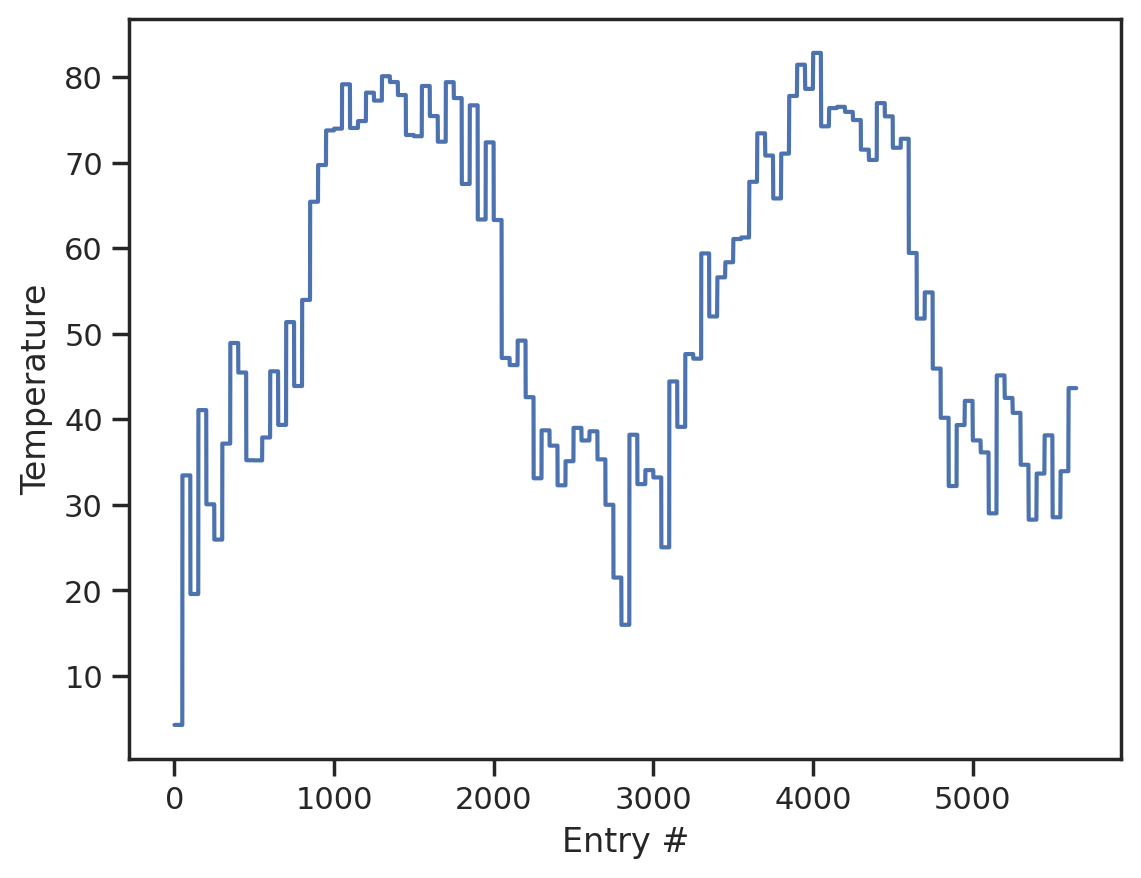

In [23]:
plt.plot(df['t_out'])
plt.xlabel("Entry #")
plt.ylabel("Temperature")

+ Extract the data pertaining to household `a5`.
Put the result in a new dataframe called `df_a5`.

In [25]:
df_a5 = df[df['household'] == 'a5']
df_a5.head()

,household,date,score,t_out,t_unit,hvac
11,a5,2018-01-07,64.0,4.283373,74.854456,286.011150
61,a5,2018-01-14,78.0,33.444172,74.786855,137.786711
111,a5,2018-01-21,67.0,19.584102,75.463740,229.760337
161,a5,2018-01-28,74.0,41.076513,75.382341,79.433718
211,a5,2018-02-04,64.0,30.065774,75.676811,118.032515


+ For household `a5`, plot `t_unit` as a function of date.

Text(0, 0.5, 'Temperature')

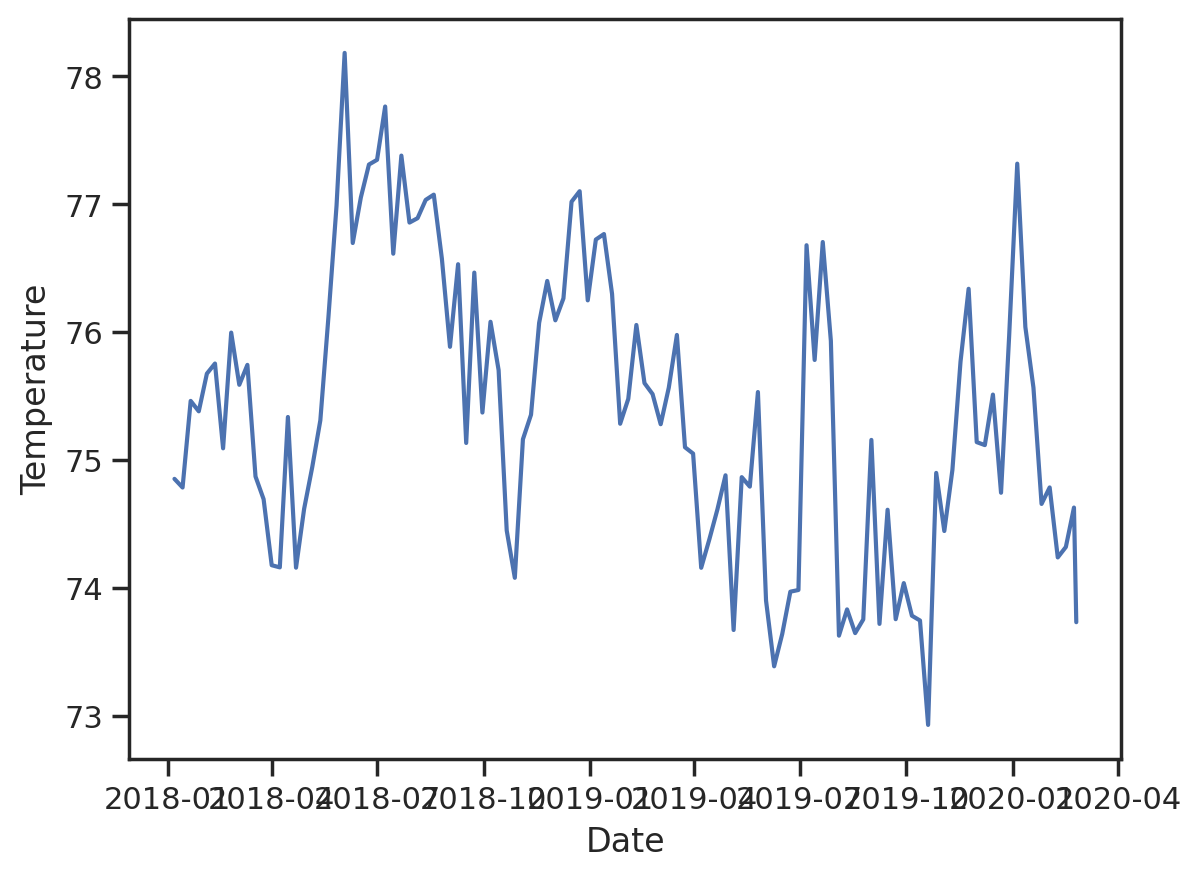

In [26]:
plt.plot(df_a5['date'], df_a5['t_unit'])
plt.xlabel("Date")
plt.ylabel("Temperature")

+ In a single figure, plot `date` vs `t_unit` for households `a5` and `a11`.

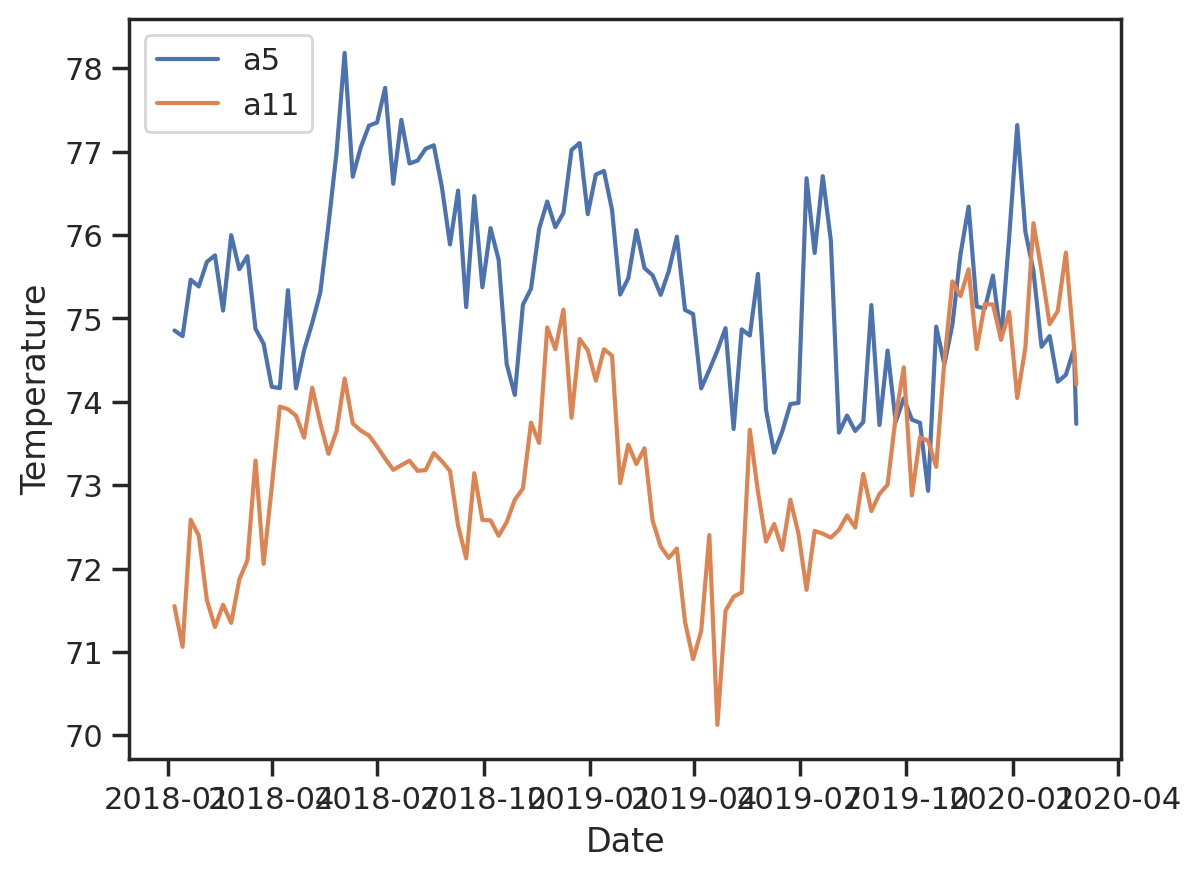

In [38]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
df_a11 = df[df['household'] == 'a11']

ax.plot(df_a5['date'], df_a5['t_unit'], label='a5')
ax.plot(df_a11['date'], df_a11['t_unit'], label='a11')

ax.set_xlabel('Date')
ax.set_ylabel('Temperature')
ax.legend()

+ In the same figure, plot the `t_out` and `t_unit` scatter plots for both households `a5` and `a11`.

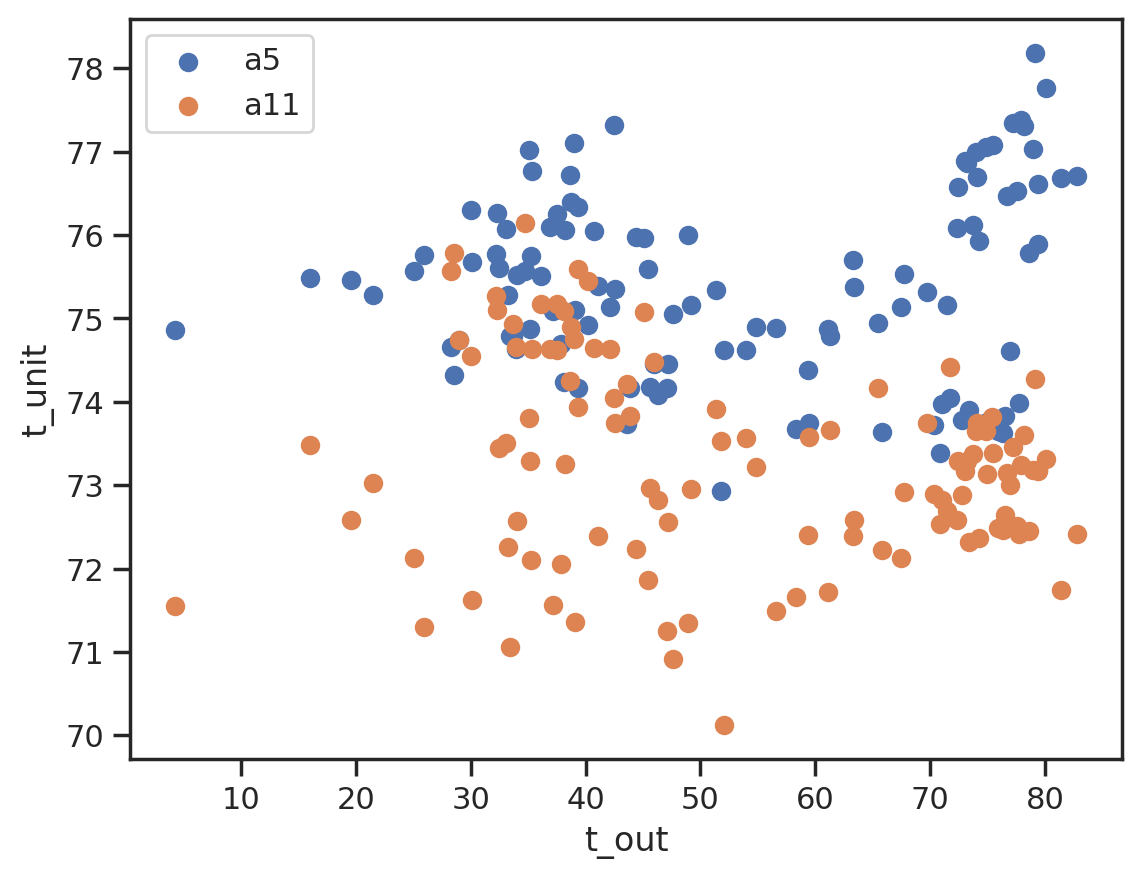

In [43]:
plt.scatter(df_a5['t_out'], df_a5['t_unit'], label='a5')
plt.scatter(df_a11['t_out'], df_a11['t_unit'], label='a11')
plt.xlabel("t_out")
plt.ylabel("t_unit")
plt.legend()
plt.show()

+ In the same figure, plot the `t_out` and `hvac` scatter plots for both households `a5` and `a11`.

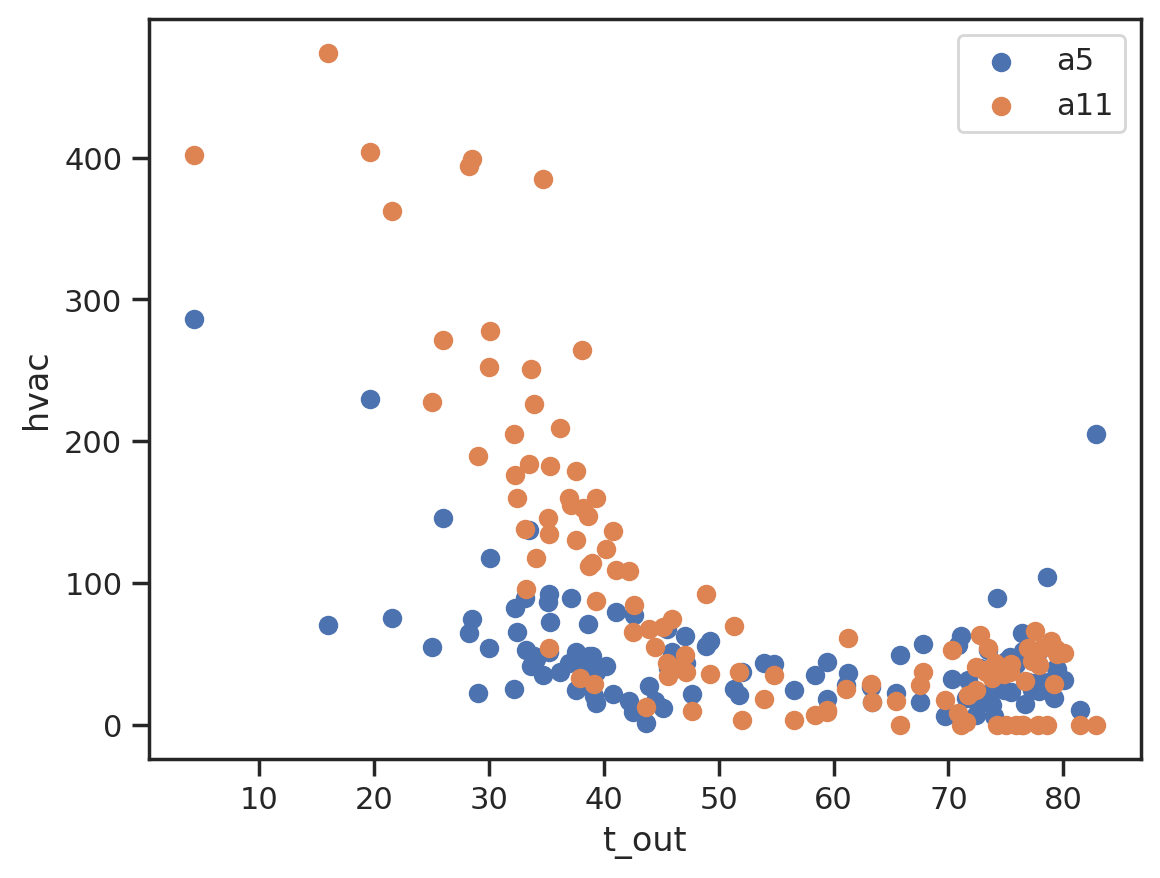

In [44]:
plt.scatter(df_a5['t_out'], df_a5['hvac'], label='a5')
plt.scatter(df_a11['t_out'], df_a11['hvac'], label='a11')
plt.xlabel("t_out")
plt.ylabel("hvac")
plt.legend()
plt.show()

+ In the same figure, plot the histogram of `t_unit` for households `a5` and `a11`.
Which household prefers cooler temperatures?
Hint: To make the histogram more appealing use the keywords ``density=True, alpha=0.25``.

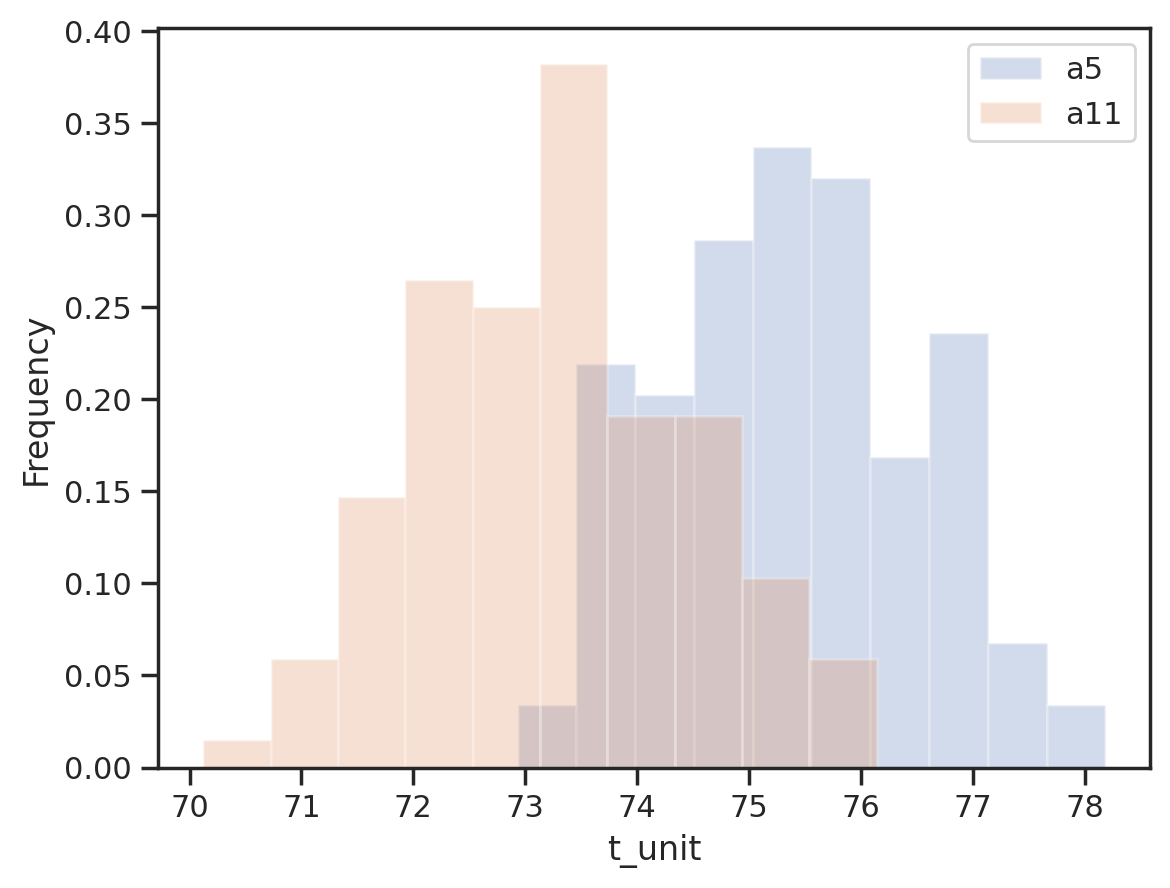

In [47]:
plt.hist(df_a5['t_unit'], density=True, alpha=0.25, label='a5')
plt.hist(df_a11['t_unit'], density=True, alpha=0.25, label='a11')
plt.xlabel("t_unit")
plt.ylabel("Frequency")
plt.legend()
plt.show()

*Based on the histograms above, the a11 household prefers cooler temperatures as the majority of the red bars are to the left of the blue bars. This clearly is shown by the x-axis labels showing lower temperatures, with the most between 73 and 74.*

+ In the same figure, plot the histogram of `hvac` for households `a5` and `a11`.
Which household is more energy efficient (if any) and why?

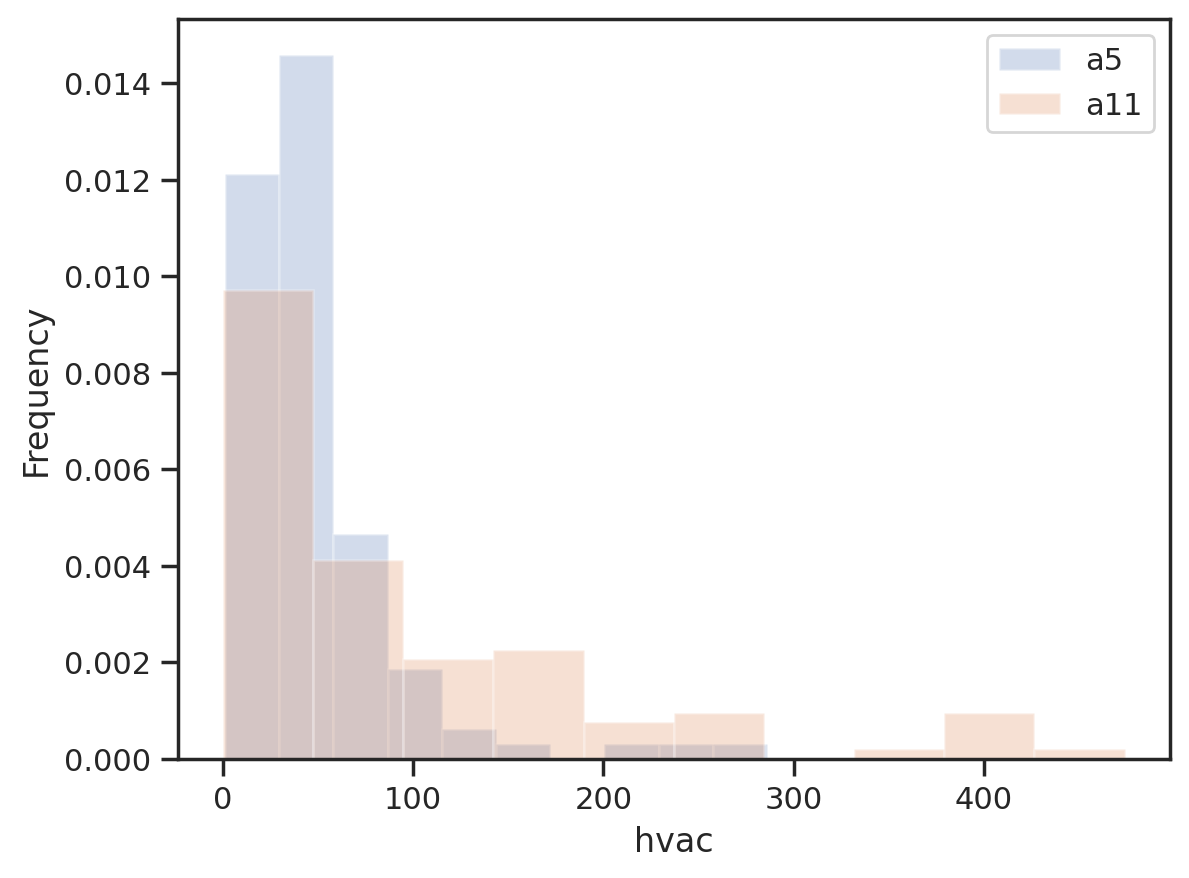

In [49]:
plt.hist(df_a5['hvac'], density=True, alpha=0.25, label='a5')
plt.hist(df_a11['hvac'], density=True, alpha=0.25, label='a11')
plt.xlabel("hvac")
plt.ylabel("Frequency")
plt.legend()
plt.show()

*As shown by the histogram, the a5 household is more energy efficient than the a11 household. This is because its hvac consumption is more more clumped together and much lower than that of a11, which means it uses less energy and as such is more more energy efficient.*

+ Repeat the analysis above for households `b17` and `c40`. Which household prefers cooler temperatures and which one is more energy efficient?

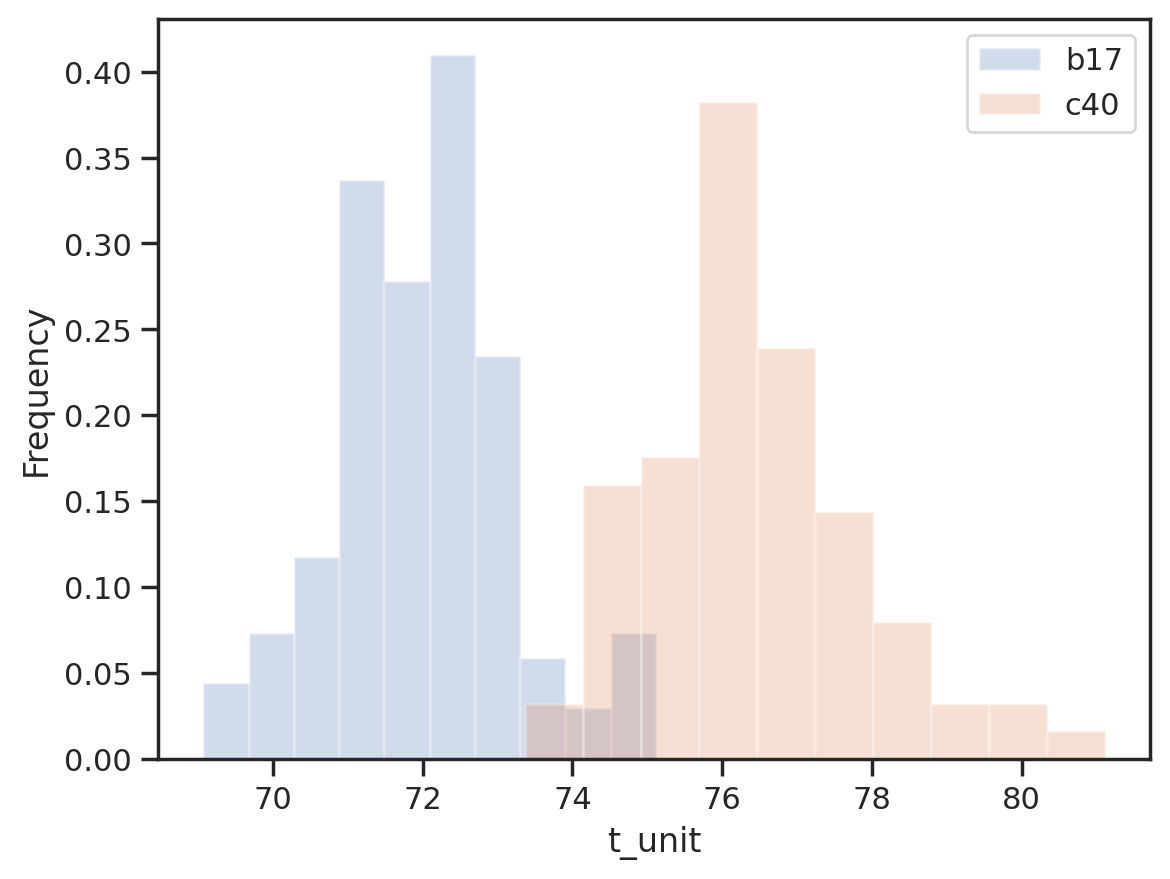

In [51]:
df_b17 = df[df['household'] == 'b17']
df_c40 = df[df['household'] == 'c40']

plt.hist(df_b17['t_unit'], density=True, alpha=0.25, label='b17')
plt.hist(df_c40['t_unit'], density=True, alpha=0.25, label='c40')
plt.xlabel("t_unit")
plt.ylabel("Frequency")
plt.legend()
plt.show()

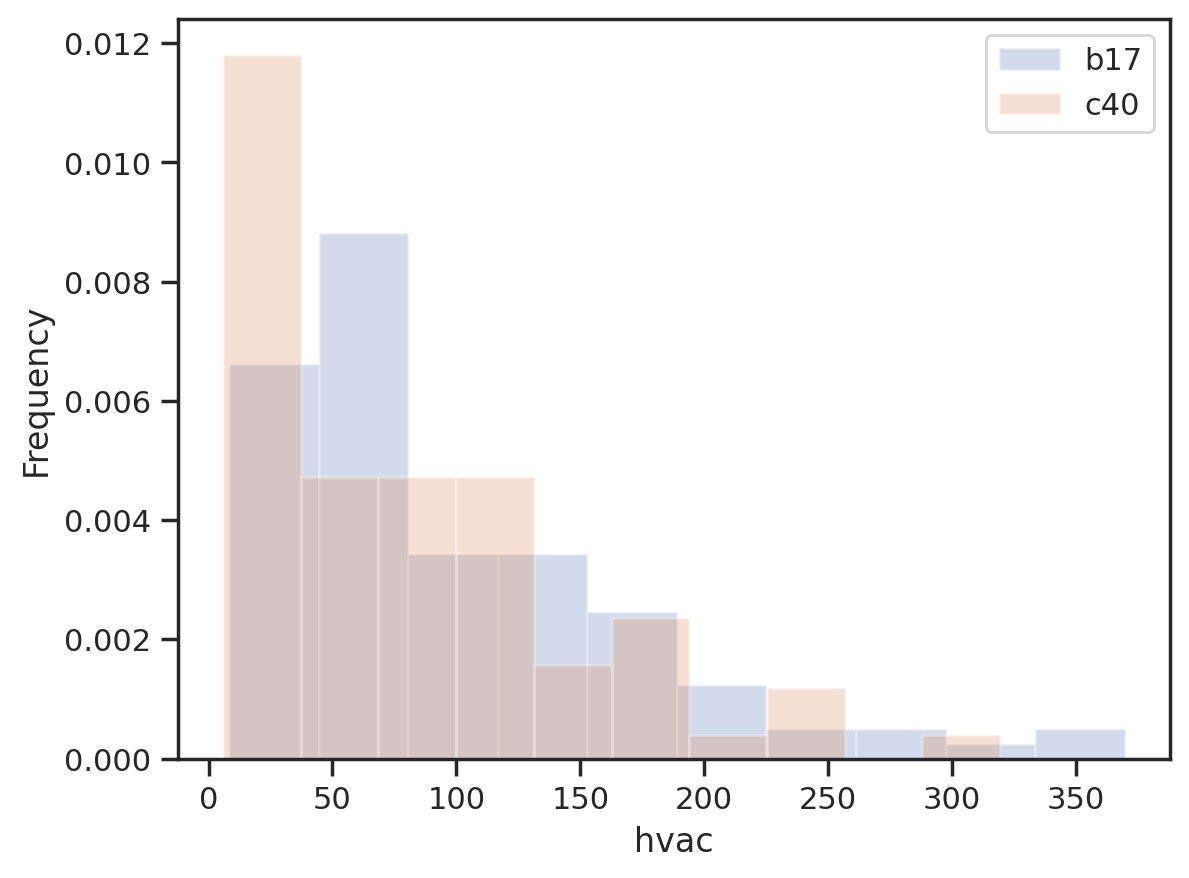

In [52]:
plt.hist(df_b17['hvac'], density=True, alpha=0.25, label='b17')
plt.hist(df_c40['hvac'], density=True, alpha=0.25, label='c40')
plt.xlabel("hvac")
plt.ylabel("Frequency")
plt.legend()
plt.show()

*For the b17 and c40 households, after conducting histogram analysis, the conclusion is that the c40  household is more neergy efficient than the b17. The b17 household prefers cooler temperatures. This is because the c40 household prefers warmer temperatures and concentrates its hvac towards the lower end of the spectrum, avoiding high numbers and using less energy, thereofre making it more energy efficient.*

Run the following code to convert the notebook to a pdf. Verify that the file path to the notebook is correct.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!apt-get install inkscape texlive texlive-xetex texlive-latex-extra pandoc --quiet
!pip install pypandoc --quiet
!jupyter nbconvert --to PDF '/content/drive/MyDrive/Colab Notebooks/Copy of homework_06.ipynb'